# Molecular prediction by class stratum (axis-200-900)

Head metrics per class stratum (training support, frequency, class set, presence in the held-out images) and a diagnosis of the extension range: does the model predict the molecules of the new m/z range, or does it predict nothing there?

## Introduction

A macro average over all classes mixes classes with thousands of training positives with classes seen a few
times, and on the wide axis classes of the common range with classes that exist only on the extension. The
strata separate these; the extension diagnostics look at the raw predicted probabilities of each class.

### Assumptions

* `test` pixels come from training images and are spatially correlated with training pixels; `heldout_image`
  pixels come from three images never seen during training. Generalization to new images is therefore judged on
  `heldout_image`, generalization to new pixels on `test`.
* Repetitions differ only in initialization and training seed; they share the split. Five repetitions per axis
  are the experimental units for model-level statements; pixels are not independent units.

* The head was trained with the variational PU loss: annotations are positive, missing annotations are unlabelled.
  `annotation_retrieval` therefore treats unlabelled entries as negatives and underestimates precision when
  annotations are incomplete; `operational_pn` removes entries with signal but no annotation.
* Threshold metrics use $\hat Y \ge 0.5$; VPU logits are treated as 0.5-anchored as in the earlier head analyses.
* Evaluations: `train`, `test`, `test_extended`, `test_combined` (test and extension together, the main per-class
  estimate for rare classes) and `heldout_image`.

        * On the narrow axis every class is `common`; the class-set strata and extension diagnostics are informative on
          the wide axis only.
        * `acquired_fraction` is the fraction of evaluated pixels whose input carries at least $10^{-3}$ of its TIC in
          the class's 100 Da window; a class cannot be detected in pixels where its window was not acquired.

### Notation

* $X \in \mathbb{R}_{\ge 0}^{M}$: TIC-normalized input spectrum on the axis ($M$ bins of 0.55 Da);
  $\hat X = \mathrm{Dec}(\mathrm{Enc}(X))$: its reconstruction (TIC-normalized decoder output).
* $Z = \mathrm{Enc}(X) \in \mathbb{R}^{10}$: latent code; $U$: canonicalized code (bottleneck LayerNorm affine
  removed; rows lie on a sphere of radius $\sqrt{10}$ with zero row sum).
* $\hat Y = \sigma(h(Z)) \in [0, 1]^{C}$: head probabilities of the $C$ train-observed molecule classes.
* $P \in \{\mathrm{train}, \mathrm{test}, \mathrm{test\_extended}, \mathrm{heldout\_image}\}$: pixel population;
  $r = 0, \dots, 4$: repetition (independent training seed of the same configuration).
* $W_1(X, \hat X)$: training Masserstein cost, the exact one-dimensional Wasserstein-1 distance between the
  TIC-normalized spectra, in m/z units.
* Window $W = [a, a + 100)$ m/z, aligned to multiples of 100 on every axis.

* Ranking populations: `annotation_retrieval` (every available entry; annotated = positive, everything else
  negative) and `operational_pn` (only evidence positives P and operational negatives N; unlabelled entries with
  signal at the ion's bins, U, are excluded). Evidence rule: peak above 1.19 % of the spectrum maximum within
  +/- 1 bin.
* AP: average precision per class; macro = mean over eligible classes (at least one positive and one negative in
  the evaluated population and training support); micro = one ranking over all eligible entries.

## Configuration

In [1]:
import logging
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# Library modules log INFO to stdout; warnings stay visible, progress messages do not.
logging.disable(logging.INFO)
current_path = Path.cwd().resolve()
repository_root = next(path for path in (current_path, *current_path.parents) if (path / "pyproject.toml").is_file())
os.chdir(repository_root)

from msi_autoencoder_wrapper.analysis.autoencoder.experiments import pretraining_campaign as campaign
from msi_autoencoder_wrapper.analysis.autoencoder.experiments.pretraining_campaign_precompute import (
    load_metadata, load_table, run_command,
)
from msi_autoencoder_wrapper.analysis.precompute.notebook_inputs import load_model_catalog, load_visualization_theme
from msi_autoencoder_wrapper.visualization import pretraining as figures

SETTINGS_PATH = Path("assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/analysis_settings.yaml")
ANALYSIS = "prediction_class_strata"
AXIS = "axis-200-900"

settings = campaign.load_settings(SETTINGS_PATH)
theme = load_visualization_theme(settings).with_overrides(figure_dpi=100)
catalog = load_model_catalog(settings)
metadata = load_metadata(settings, ANALYSIS, AXIS)
pd.set_option("display.precision", 4)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 80)


def table(name: str) -> pd.DataFrame:
    """Load one canonical table written for this notebook by the precompute."""
    return load_table(settings, ANALYSIS, name, AXIS)


def mean_sd(frame: pd.DataFrame, keys: list, columns: list) -> pd.DataFrame:
    """Mean and SD over repetitions of the given columns (presentation helper)."""
    long = frame.melt(id_vars=keys, value_vars=columns, var_name="quantity", value_name="value")
    return long.groupby([*keys, "quantity"]).value.agg(["mean", "std"]).unstack("quantity")


LABELS = list(catalog.drop_duplicates("display_label").sort_values("display_order").display_label)
LABEL_COLORS = {label: figures.model_color(label, theme, position) for position, label in enumerate(LABELS)}
POPULATION_COLORS = {name: figures.population_color(name, theme) for name in figures.POPULATION_ORDER}
CLASS_SET_COLORS = {name: figures.class_set_color(name, theme) for name in figures.CLASS_SET_ORDER}
print("Analysis:", ANALYSIS, "| axis:", AXIS, "| models:", len(metadata["models"]))
print("Cache keys:", metadata["cache_keys"])

POPULATIONS = ['train', 'test', 'test_extended', 'heldout_image']
AXIS_LABEL = settings['axes'][AXIS]['label']
MODEL_LABEL = catalog[catalog.axis == AXIS].display_label.iloc[0]
DATASETS = sorted(load_table(settings, 'heldout_image_reconstruction', 'image_metrics', AXIS).dataset_id.unique())
print('Axis label:', AXIS_LABEL, '| held-out images:', DATASETS)

EVALUATIONS = ['train', 'test', 'test_combined', 'heldout_image']
EVALUATION_COLORS = {name: POPULATION_COLORS[name] for name in EVALUATIONS}
METRIC_ORDER = ['average_precision', 'micro_average_precision', 'roc_auc', 'micro_roc_auc', 'ap_above_prevalence',
                'micro_prevalence', 'precision', 'recall', 'f1', 'micro_precision', 'micro_recall', 'micro_f1',
                'hamming_loss']


def metric_table(frame, index, columns, column_order):
    """Mean +/- SD over repetitions of every metric of a long table (`metric`, `value`)."""
    long = frame.drop(columns=[name for name in ('axis',) if name in frame.columns]).copy()
    long['metric'] = pd.Categorical(long.metric, categories=[name for name in METRIC_ORDER if name in set(long.metric)], ordered=True)
    grouped = long.groupby([*index, 'metric', columns], observed=True).value
    cells = grouped.mean().map('{:.4f}'.format) + ' +/- ' + grouped.std().map('{:.4f}'.format)
    shown = cells.unstack(columns)
    return shown[[name for name in column_order if name in shown.columns]]


def metric_columns_table(frame, index):
    """Mean +/- SD over repetitions of every metric column of a wide table."""
    columns = [name for name in METRIC_ORDER if name in frame.columns]
    grouped = frame.drop(columns=[name for name in ('axis',) if name in frame.columns]).groupby(index)[columns]
    return grouped.mean().round(4).astype(str) + ' +/- ' + grouped.std().round(4).astype(str)

all_strata = table('strata_metrics')
strata = all_strata[(all_strata.group == 'all') & (all_strata.population == 'annotation_retrieval')]

Analysis: prediction_class_strata | axis: axis-200-900 | models: 5
Cache keys: {'plan': 'f34a92a8f6f7833f', 'populations': '513690bdd78a83ce', 'inference': '0243c1efb93b9c4c'}
Axis label: 200-900 m/z | held-out images: ['2024-02-20_01h45m20s', '2024-02-20_01h46m58s', '2024-02-20_01h54m41s']


## Producing the tables this notebook reads

### Methodology

#### Implementation

`prediction_class_strata` joins the per-class ranking tables with class metadata and evaluates stored probabilities for the diagnostics.

The command below is generated by the precompute entry point itself; if a table is missing, `load_table` raises with the same command.

In [2]:
print(run_command(settings, ANALYSIS))

nohup uv run --extra cu118 python -m msi_autoencoder_wrapper.analysis.precompute --settings /home/max/repositories/MSIAutoEncoderWrapper/assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/analysis_settings.yaml --analysis prediction_class_strata > /home/max/repositories/MSIAutoEncoderWrapper/assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/shared_precompute.log 2>&1 &


### Remarks

### Notes

## Macro AP by training support

### Methodology

#### Theoretical

The macro AP within a stratum shows how prediction quality depends on the stratifying property.

#### Implementation

`strata_metrics` rows with grouping `train_support`, ranking population `annotation_retrieval`.

#### Figure descriptions

x = stratum, colour = evaluation population, one point per repetition, bar = mean. Tables: eligible classes, then the complete metric set per evaluation population and stratum (mean +/- SD over repetitions).

/home/max/repositories/MSIAutoEncoderWrapper/src/msi_autoencoder_wrapper/visualization/pretraining.py:152: RuntimeWarning: Mean of empty slice
  ax.hlines(np.nanmean(values), x - width / 2.5, x + width / 2.5, color=colors[level], linewidth=2)


evaluation,train,test,test_combined,heldout_image
stratum,,,,
1-9,15.0,15.0,15.0,1.0
10-99,67.0,67.0,67.0,0.0
100-999,140.0,140.0,140.0,1.0
1000+,286.0,286.0,286.0,15.0


average_precision micro_average_precision            roc_auc      micro_roc_auc ap_above_prevalence micro_prevalence          precision             recall                 f1  \
evaluation    stratum                                                                                                                                                                                  
heldout_image 1-9      0.0017 +/- 0.0006       0.0017 +/- 0.0006   0.879 +/- 0.0213   0.879 +/- 0.0213   0.0014 +/- 0.0006   0.0003 +/- 0.0        0.0 +/- 0.0        0.0 +/- 0.0        0.0 +/- 0.0   
              10-99                  NaN                     NaN                NaN                NaN                 NaN              NaN                NaN                NaN                NaN   
              100-999  0.7131 +/- 0.0486       0.7131 +/- 0.0486  0.9628 +/- 0.0076  0.9628 +/- 0.0076   0.5768 +/- 0.0486   0.1363 +/- 0.0     0.4 +/- 0.5477  0.0009 +/- 0.0019  0.0018 +/- 0.0037   
              1000+    0.3554 +/- 0.0105       0.5975 +/- 0.0104  0.6667 +/- 0.0091  0.7896 +/- 0.0059   0.0994 +/- 0.0105    0.256 +/- 0.0  0.3559 +/- 0.0201  0.1516 +/- 0.0156  0.1587 +/- 0.0172   
test          1-9        0.28 +/- 0.0668       0.0504 +/- 0.0605  0.9774 +/- 0.0033  0.9832 +/- 0.0016   0.2797 +/- 0.0668   0.0003 +/- 0.0  0.0591 +/- 0.0584  0.1733 +/- 0.1011  0.0641 +/- 0.0606   
              10-99      0.248 +/- 0.023       0.0498 +/- 0.0037  0.9871 +/- 0.0027  0.9876 +/- 0.0021    0.2473 +/- 0.023   0.0007 +/- 0.0  0.0202 +/- 0.0139  0.0816 +/- 0.0185  0.0191 +/- 0.0076   
              100-999  0.6303 +/- 0.0062       0.6259 +/- 0.0408  0.9941 +/- 0.0002  0.9956 +/- 0.0004   0.6236 +/- 0.0062   0.0067 +/- 0.0  0.3173 +/- 0.0463  0.2167 +/- 0.0256  0.2214 +/- 0.0241   
              1000+    0.8536 +/- 0.0029       0.8931 +/- 0.0096  0.9876 +/- 0.0002  0.9926 +/- 0.0004   0.7638 +/- 0.0029   0.0898 +/- 0.0  0.8228 +/- 0.0098  0.7504 +/- 0.0105  0.7484 +/- 0.0085   
test_combined 1-9      0.1764 +/- 0.0136       0.0508 +/- 0.0149  0.9582 +/- 0.0028  0.9451 +/- 0.0053    0.173 +/- 0.0136   0.0034 +/- 0.0  0.0667 +/- 0.0412  0.1047 +/- 0.0663  0.0279 +/- 0.0145   
              10-99    0.2664 +/- 0.0071        0.0722 +/- 0.002   0.9743 +/- 0.001   0.969 +/- 0.0008   0.2618 +/- 0.0071   0.0046 +/- 0.0  0.0527 +/- 0.0223  0.0914 +/- 0.0257  0.0221 +/- 0.0072   
              100-999  0.6671 +/- 0.0044       0.7342 +/- 0.0228  0.9911 +/- 0.0001  0.9935 +/- 0.0004   0.6496 +/- 0.0044   0.0175 +/- 0.0  0.3529 +/- 0.0688  0.2251 +/- 0.0283  0.2346 +/- 0.0282   
              1000+    0.8608 +/- 0.0027       0.9015 +/- 0.0082  0.9888 +/- 0.0002  0.9927 +/- 0.0003   0.7667 +/- 0.0027   0.0941 +/- 0.0   0.8307 +/- 0.011  0.7458 +/- 0.0112  0.7502 +/- 0.0096   
train         1-9      0.1337 +/- 0.0144       0.0085 +/- 0.0075  0.9929 +/- 0.0011  0.9892 +/- 0.0025   0.1336 +/- 0.0144   0.0001 +/- 0.0  0.0201 +/- 0.0129   0.1105 +/- 0.066  0.0207 +/- 0.0138   
              10-99    0.1698 +/- 0.0081        0.0436 +/- 0.003  0.9937 +/- 0.0005  0.9916 +/- 0.0006   0.1693 +/- 0.0081   0.0006 +/- 0.0  0.0309 +/- 0.0113  0.0909 +/- 0.0258  0.0175 +/- 0.0056   
              100-999  0.6099 +/- 0.0037       0.6277 +/- 0.0417  0.9947 +/- 0.0002  0.9957 +/- 0.0004   0.6034 +/- 0.0037   0.0065 +/- 0.0  0.3872 +/- 0.0601   0.216 +/- 0.0271  0.2238 +/- 0.0266   
              1000+    0.8562 +/- 0.0029       0.8933 +/- 0.0094  0.9878 +/- 0.0002  0.9926 +/- 0.0004   0.7665 +/- 0.0029   0.0896 +/- 0.0  0.8366 +/- 0.0103  0.7528 +/- 0.0097   0.7508 +/- 0.008   

                         micro_precision       micro_recall           micro_f1       hamming_loss  
evaluation    stratum                                                                              
heldout_image 1-9            0.0 +/- 0.0        0.0 +/- 0.0        0.0 +/- 0.0     0.0003 +/- 0.0  
              10-99          0.0 +/- 0.0        0.0 +/- 0.0        0.0 +/- 0.0                NaN  
              100-999 

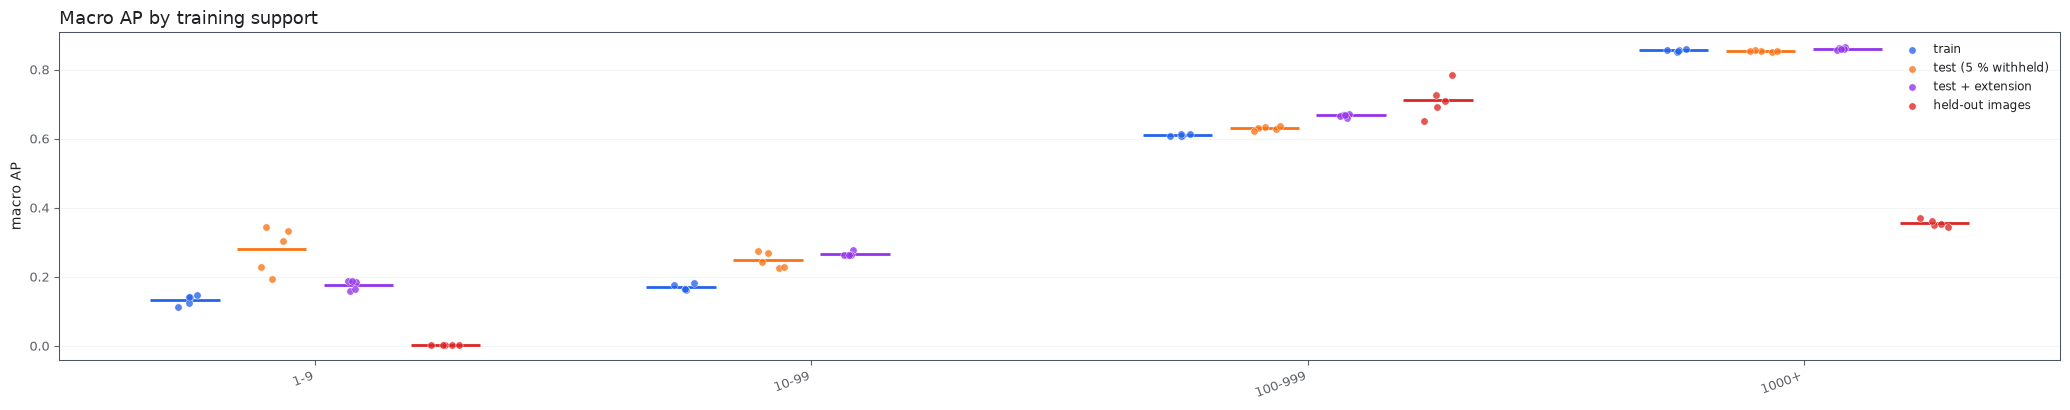

In [3]:
shown = strata[strata.grouping == 'train_support']
order = ['1-9', '10-99', '100-999', '1000+']
figures.repetition_points(shown, value='average_precision', group='stratum', hue='evaluation', order=order, hue_order=EVALUATIONS, colors=EVALUATION_COLORS, ylabel='macro AP', title='Macro AP by training support', theme=theme);
display(shown[shown.repetition == 0].pivot_table(index='stratum', columns='evaluation', values='eligible_classes')[[name for name in EVALUATIONS if name in set(shown.evaluation)]])
display(metric_columns_table(shown[shown.evaluation.isin(EVALUATIONS)], ['evaluation', 'stratum']))

### Remarks

- Classes with fewer than 100 training positives reach macro AP 0.18-0.27 (test + extension); classes with 1000+ positives 0.86.
- On held-out images the rare classes are essentially not detected (0.002).

### Notes

## Macro AP by frequency bucket

### Methodology

#### Theoretical

The macro AP within a stratum shows how prediction quality depends on the stratifying property.

#### Implementation

`strata_metrics` rows with grouping `frequency`, ranking population `annotation_retrieval`.

#### Figure descriptions

x = stratum, colour = evaluation population, one point per repetition, bar = mean. Tables: eligible classes, then the complete metric set per evaluation population and stratum (mean +/- SD over repetitions).

/home/max/repositories/MSIAutoEncoderWrapper/src/msi_autoencoder_wrapper/visualization/pretraining.py:152: RuntimeWarning: Mean of empty slice
  ax.hlines(np.nanmean(values), x - width / 2.5, x + width / 2.5, color=colors[level], linewidth=2)


evaluation,train,test,test_combined,heldout_image
stratum,,,,
frequent,426.0,426.0,426.0,16.0
medium,67.0,67.0,67.0,0.0
rare,15.0,15.0,15.0,1.0


average_precision micro_average_precision            roc_auc micro_roc_auc ap_above_prevalence micro_prevalence          precision             recall                 f1  \
evaluation    stratum                                                                                                                                                                              
heldout_image frequent  0.3778 +/- 0.0079                     NaN  0.6852 +/- 0.0082           NaN   0.1293 +/- 0.0079              NaN  0.3586 +/- 0.0371  0.1421 +/- 0.0147  0.1489 +/- 0.0162   
              medium                  NaN                     NaN                NaN           NaN                 NaN              NaN                NaN                NaN                NaN   
              rare      0.0017 +/- 0.0006                     NaN   0.879 +/- 0.0213           NaN   0.0014 +/- 0.0006              NaN        0.0 +/- 0.0        0.0 +/- 0.0        0.0 +/- 0.0   
test          frequent  0.7802 +/- 0.0031                     NaN  0.9897 +/- 0.0002           NaN   0.7177 +/- 0.0031              NaN  0.6567 +/- 0.0185   0.575 +/- 0.0139  0.5752 +/- 0.0114   
              medium      0.248 +/- 0.023                     NaN  0.9871 +/- 0.0027           NaN    0.2473 +/- 0.023              NaN  0.0202 +/- 0.0139  0.0816 +/- 0.0185  0.0191 +/- 0.0076   
              rare        0.28 +/- 0.0668                     NaN  0.9774 +/- 0.0033           NaN   0.2797 +/- 0.0668              NaN  0.0591 +/- 0.0584  0.1733 +/- 0.1011  0.0641 +/- 0.0606   
test_combined frequent  0.7971 +/- 0.0029                     NaN  0.9896 +/- 0.0001           NaN   0.7282 +/- 0.0029              NaN  0.6737 +/- 0.0249  0.5747 +/- 0.0155  0.5808 +/- 0.0135   
              medium    0.2664 +/- 0.0071                     NaN   0.9743 +/- 0.001           NaN   0.2618 +/- 0.0071              NaN  0.0527 +/- 0.0223  0.0914 +/- 0.0257  0.0221 +/- 0.0072   
              rare      0.1764 +/- 0.0136                     NaN  0.9582 +/- 0.0028           NaN    0.173 +/- 0.0136              NaN  0.0667 +/- 0.0412  0.1047 +/- 0.0663  0.0279 +/- 0.0145   
train         frequent  0.7752 +/- 0.0027                     NaN  0.9901 +/- 0.0002           NaN   0.7129 +/- 0.0027              NaN  0.6889 +/- 0.0239   0.5764 +/- 0.014  0.5776 +/- 0.0121   
              medium    0.1698 +/- 0.0081                     NaN  0.9937 +/- 0.0005           NaN   0.1693 +/- 0.0081              NaN  0.0309 +/- 0.0113  0.0909 +/- 0.0258  0.0175 +/- 0.0056   
              rare      0.1337 +/- 0.0144                     NaN  0.9929 +/- 0.0011           NaN   0.1336 +/- 0.0144              NaN  0.0201 +/- 0.0129   0.1105 +/- 0.066  0.0207 +/- 0.0138   

                       micro_precision micro_recall micro_f1 hamming_loss  
evaluation    stratum                                                      
heldout_image frequent             NaN          NaN      NaN          NaN  
              medium               NaN          NaN      NaN          NaN  
              rare                 NaN          NaN      NaN          NaN  
test          frequent             NaN          NaN      NaN          NaN  
              medium               NaN          NaN      NaN          NaN  
              rare                 NaN          NaN      NaN          NaN  
test_combined frequent             NaN          NaN      NaN          NaN  
              medium               NaN          NaN      NaN          NaN  
              rare                 NaN          NaN      NaN          NaN  
train         frequent             NaN          NaN      NaN          NaN  
              medium               NaN          NaN      NaN          NaN  
              rare                 NaN          NaN      NaN          NaN

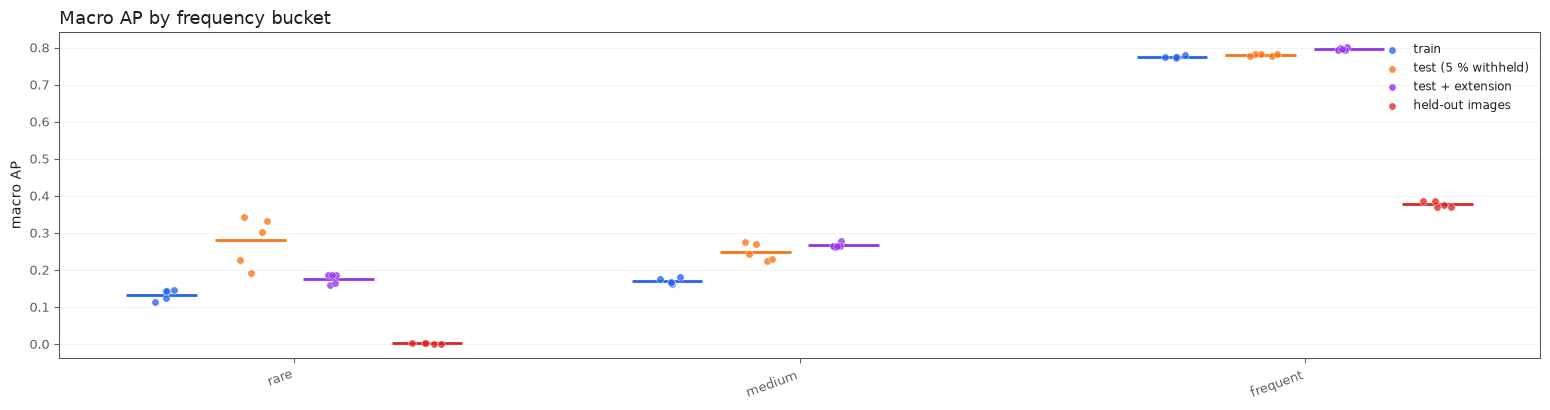

In [4]:
shown = strata[strata.grouping == 'frequency']
order = ['rare', 'medium', 'frequent']
figures.repetition_points(shown, value='average_precision', group='stratum', hue='evaluation', order=order, hue_order=EVALUATIONS, colors=EVALUATION_COLORS, ylabel='macro AP', title='Macro AP by frequency bucket', theme=theme);
display(shown[shown.repetition == 0].pivot_table(index='stratum', columns='evaluation', values='eligible_classes')[[name for name in EVALUATIONS if name in set(shown.evaluation)]])
display(metric_columns_table(shown[shown.evaluation.isin(EVALUATIONS)], ['evaluation', 'stratum']))

### Remarks

- Note: the frequency buckets come from the whole-axis ranking table, which reports micro metrics only for the training-supported scope; the `train_support` buckets above carry the complete metric set.

### Notes

## Macro AP by class set

### Methodology

#### Theoretical

The macro AP within a stratum shows how prediction quality depends on the stratifying property.

#### Implementation

`strata_metrics` rows with grouping `class_set`, ranking population `annotation_retrieval`.

#### Figure descriptions

x = stratum, colour = evaluation population, one point per repetition, bar = mean. Tables: eligible classes, then the complete metric set per evaluation population and stratum (mean +/- SD over repetitions).

evaluation,train,test,test_combined,heldout_image
stratum,,,,
common,508.0,508.0,508.0,17.0


,,average_precision,micro_average_precision,roc_auc,micro_roc_auc,ap_above_prevalence,micro_prevalence,precision,recall,f1,micro_precision,micro_recall,micro_f1,hamming_loss
evaluation,stratum,,,,,,,,,,,,,
heldout_image,common,0.3557 +/- 0.0075,0.5924 +/- 0.0097,0.6966 +/- 0.0084,0.8096 +/- 0.0038,0.1217 +/- 0.0075,0.2339 +/- 0.0,0.3375 +/- 0.0349,0.1338 +/- 0.0138,0.1401 +/- 0.0153,0.6637 +/- 0.0064,0.3063 +/- 0.0202,0.4189 +/- 0.02,0.1986 +/- 0.0032
test,common,0.6953 +/- 0.0034,0.8868 +/- 0.0096,0.989 +/- 0.0005,0.9953 +/- 0.0002,0.6428 +/- 0.0034,0.0525 +/- 0.0,0.5551 +/- 0.0181,0.4981 +/- 0.0158,0.4868 +/- 0.0112,0.8402 +/- 0.0059,0.86 +/- 0.006,0.85 +/- 0.0028,0.0159 +/- 0.0003
test_combined,common,0.7088 +/- 0.0033,0.8828 +/- 0.0088,0.9866 +/- 0.0003,0.9938 +/- 0.0003,0.6503 +/- 0.0033,0.0585 +/- 0.0,0.5739 +/- 0.0236,0.4971 +/- 0.0164,0.4908 +/- 0.0121,0.8469 +/- 0.009,0.8063 +/- 0.0072,0.8261 +/- 0.0048,0.0199 +/- 0.0006
train,common,0.6764 +/- 0.0034,0.8873 +/- 0.0094,0.9906 +/- 0.0002,0.9953 +/- 0.0002,0.6241 +/- 0.0034,0.0523 +/- 0.0,0.5824 +/- 0.0213,0.4986 +/- 0.016,0.4873 +/- 0.0109,0.8405 +/- 0.006,0.8616 +/- 0.0057,0.8509 +/- 0.0025,0.0158 +/- 0.0003


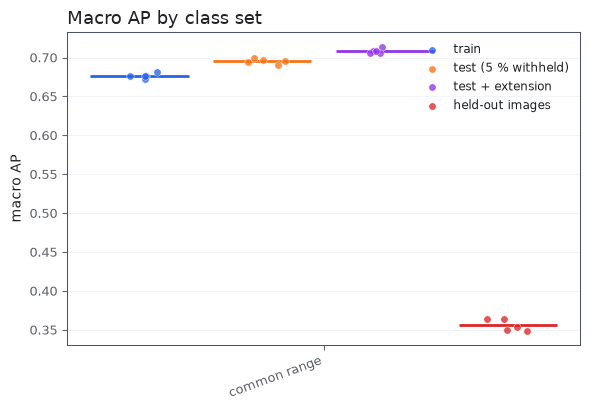

In [5]:
shown = strata[strata.grouping == 'class_set']
order = [value for value in figures.CLASS_SET_ORDER if value in set(strata.stratum)]
figures.repetition_points(shown, value='average_precision', group='stratum', hue='evaluation', order=order, hue_order=EVALUATIONS, colors=EVALUATION_COLORS, ylabel='macro AP', title='Macro AP by class set', theme=theme);
display(shown[shown.repetition == 0].pivot_table(index='stratum', columns='evaluation', values='eligible_classes')[[name for name in EVALUATIONS if name in set(shown.evaluation)]])
display(metric_columns_table(shown[shown.evaluation.isin(EVALUATIONS)], ['evaluation', 'stratum']))

### Remarks

- Only the common class set exists on this axis.

### Notes

## Macro AP by presence in held-out images

### Methodology

#### Theoretical

The macro AP within a stratum shows how prediction quality depends on the stratifying property.

#### Implementation

`strata_metrics` rows with grouping `heldout_presence`, ranking population `annotation_retrieval`.

#### Figure descriptions

x = stratum, colour = evaluation population, one point per repetition, bar = mean. Tables: eligible classes, then the complete metric set per evaluation population and stratum (mean +/- SD over repetitions).

/home/max/repositories/MSIAutoEncoderWrapper/src/msi_autoencoder_wrapper/visualization/pretraining.py:152: RuntimeWarning: Mean of empty slice
  ax.hlines(np.nanmean(values), x - width / 2.5, x + width / 2.5, color=colors[level], linewidth=2)


evaluation,train,test,test_combined,heldout_image
stratum,,,,
in_heldout,17.0,17.0,17.0,17.0
not_in_heldout,491.0,491.0,491.0,0.0


average_precision micro_average_precision            roc_auc      micro_roc_auc ap_above_prevalence micro_prevalence          precision             recall  \
evaluation    stratum                                                                                                                                                                      
heldout_image in_heldout      0.3557 +/- 0.0075       0.5924 +/- 0.0097  0.6966 +/- 0.0084  0.8096 +/- 0.0038   0.1217 +/- 0.0075   0.2339 +/- 0.0  0.3375 +/- 0.0349  0.1338 +/- 0.0138   
              not_in_heldout                NaN                     NaN                NaN                NaN                 NaN              NaN                NaN                NaN   
test          in_heldout      0.7054 +/- 0.0066       0.8174 +/- 0.0061  0.9743 +/- 0.0007   0.982 +/- 0.0009   0.6075 +/- 0.0066   0.0979 +/- 0.0  0.6195 +/- 0.0276  0.4309 +/- 0.0173   
              not_in_heldout  0.6949 +/- 0.0034       0.8917 +/- 0.0104  0.9895 +/- 0.0005  0.9956 +/- 0.0002    0.644 +/- 0.0034   0.0509 +/- 0.0  0.5528 +/- 0.0179  0.5004 +/- 0.0159   
test_combined in_heldout      0.6693 +/- 0.0093       0.7993 +/- 0.0063  0.9719 +/- 0.0007   0.9801 +/- 0.001   0.5811 +/- 0.0093   0.0882 +/- 0.0  0.6113 +/- 0.0273   0.4014 +/- 0.011   
              not_in_heldout  0.7102 +/- 0.0033       0.8874 +/- 0.0094  0.9871 +/- 0.0003  0.9942 +/- 0.0003   0.6527 +/- 0.0033   0.0575 +/- 0.0  0.5726 +/- 0.0236  0.5004 +/- 0.0171   
train         in_heldout      0.6589 +/- 0.0063        0.817 +/- 0.0061  0.9745 +/- 0.0007  0.9821 +/- 0.0009   0.5612 +/- 0.0063   0.0977 +/- 0.0  0.6064 +/- 0.0181    0.42 +/- 0.0137   
              not_in_heldout   0.677 +/- 0.0035       0.8921 +/- 0.0103  0.9912 +/- 0.0002  0.9957 +/- 0.0002   0.6263 +/- 0.0035   0.0508 +/- 0.0  0.5815 +/- 0.0215  0.5013 +/- 0.0166   

                                             f1    micro_precision       micro_recall           micro_f1       hamming_loss  
evaluation    stratum                                                                                                        
heldout_image in_heldout      0.1401 +/- 0.0153  0.6637 +/- 0.0064  0.3063 +/- 0.0202    0.4189 +/- 0.02  0.1986 +/- 0.0032  
              not_in_heldout                NaN        0.0 +/- 0.0        0.0 +/- 0.0        0.0 +/- 0.0                NaN  
test          in_heldout      0.4598 +/- 0.0197  0.8529 +/- 0.0089  0.7001 +/- 0.0067   0.769 +/- 0.0041  0.0412 +/- 0.0008  
              not_in_heldout   0.4877 +/- 0.011  0.8396 +/- 0.0061  0.8706 +/- 0.0066   0.8548 +/- 0.003  0.0151 +/- 0.0003  
test_combined in_heldout       0.437 +/- 0.0084  0.8396 +/- 0.0084  0.6712 +/- 0.0099   0.746 +/- 0.0061  0.0403 +/- 0.0008  
              not_in_heldout  0.4926 +/- 0.0126  0.8472 +/- 0.0094  0.8135 +/- 0.0081    0.83 +/- 0.0052  0.0192 +/- 0.0006  
train         in_heldout      0.4491 +/- 0.0114  0.8504 +/- 0.0081  0.6981 +/- 0.0073  0.7667 +/- 0.0036  0.0415 +/- 0.0006  
              not_in_heldout  0.4886 +/- 0.0114  0.8399 +/- 0.0061  0.8725 +/- 0.0063  0.8559 +/- 0.0027  0.0149 +/- 0.0003

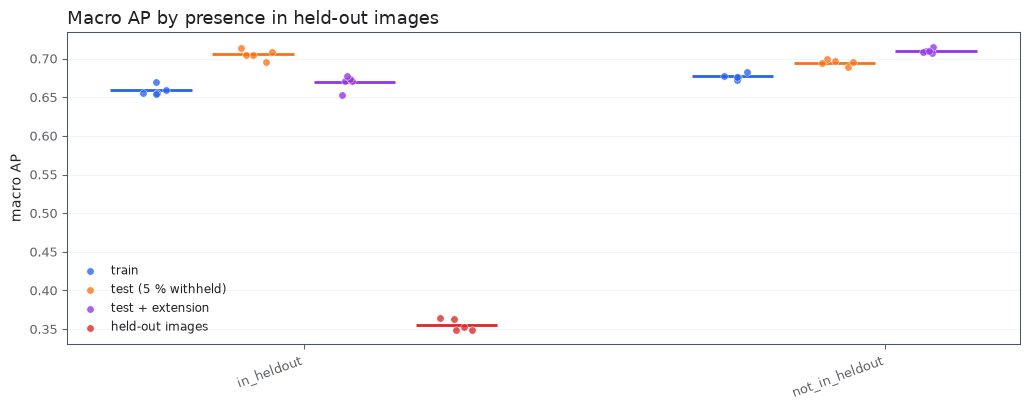

In [6]:
shown = strata[strata.grouping == 'heldout_presence']
order = ['in_heldout', 'not_in_heldout']
figures.repetition_points(shown, value='average_precision', group='stratum', hue='evaluation', order=order, hue_order=EVALUATIONS, colors=EVALUATION_COLORS, ylabel='macro AP', title='Macro AP by presence in held-out images', theme=theme);
display(shown[shown.repetition == 0].pivot_table(index='stratum', columns='evaluation', values='eligible_classes')[[name for name in EVALUATIONS if name in set(shown.evaluation)]])
display(metric_columns_table(shown[shown.evaluation.isin(EVALUATIONS)], ['evaluation', 'stratum']))

### Remarks

### Notes

## Class sets on every held-out image

### Methodology

#### Theoretical

The class-set strata evaluated per held-out image show whether an image-specific failure concerns the common
range, the boundary or the extension classes.

#### Implementation

`strata_metrics` rows with grouping `class_set` and group = held-out image, ranking population `annotation_retrieval`.

#### Figure descriptions

No figure; rows = image and class set, columns = metrics (mean +/- SD over repetitions).

In [7]:
images = all_strata[(all_strata.grouping == 'class_set') & (all_strata.group != 'all') & (all_strata.population == 'annotation_retrieval')]
display(metric_columns_table(images, ['group', 'stratum']))

,,average_precision,micro_average_precision,roc_auc,micro_roc_auc,ap_above_prevalence,micro_prevalence,precision,recall,f1,micro_precision,micro_recall,micro_f1,hamming_loss
group,stratum,,,,,,,,,,,,,
2024-02-20_01h45m20s,common,0.6224 +/- 0.0114,0.7434 +/- 0.0104,0.7284 +/- 0.0121,0.752 +/- 0.019,0.1718 +/- 0.0114,0.4506 +/- 0.0,0.5124 +/- 0.0897,0.1743 +/- 0.022,0.1974 +/- 0.0295,0.8626 +/- 0.0201,0.3186 +/- 0.0314,0.4642 +/- 0.0317,0.3303 +/- 0.0087
2024-02-20_01h46m58s,common,0.6061 +/- 0.0025,0.8351 +/- 0.0064,0.7767 +/- 0.0074,0.8888 +/- 0.0017,0.1606 +/- 0.0025,0.4455 +/- 0.0,0.3891 +/- 0.0687,0.1187 +/- 0.0054,0.1204 +/- 0.0104,0.8926 +/- 0.0024,0.2333 +/- 0.0079,0.3699 +/- 0.0101,0.354 +/- 0.0033
2024-02-20_01h54m41s,common,0.5208 +/- 0.0111,0.8358 +/- 0.0086,0.7182 +/- 0.013,0.9066 +/- 0.0061,0.1366 +/- 0.0111,0.3842 +/- 0.0,0.4274 +/- 0.0473,0.1767 +/- 0.0151,0.208 +/- 0.018,0.9115 +/- 0.0258,0.364 +/- 0.0278,0.5197 +/- 0.0287,0.258 +/- 0.0105


### Remarks

- Only common classes on this axis; per image macro AP 0.52-0.62, micro AP 0.74-0.84, micro recall 0.23-0.36.

### Notes

## Extension-range diagnostics

### Methodology

#### Theoretical

For every class and evaluation: the predicted-positive rate $\Pr(\hat Y \ge 0.5)$, the mean probability on
annotated positives and on all other entries, recall at 0.5 and the acquisition fraction of the class window.
A class set whose positives receive probabilities no higher than other entries is not learned; a set with
near-zero predicted-positive rate is predicted as absent everywhere.

#### Implementation

`extension_diagnostics` (one row per model, evaluation and class); repetition means are shown.

#### Figure descriptions

Table: medians over classes per class set and evaluation. Figure: x = mean probability on other entries, y =
mean probability on positives (repetition means, classes with at least one positive); diagonal = no
separation; colour = class set; left = test + extension, right = held-out images.

,,predicted_positive_rate,mean_probability_positive,mean_probability_other,recall_at_half,acquired_fraction
evaluation,class_set,,,,,
heldout_image,common,0.0000,0.1591,8.6589e-06,0.0092,1.0
test_combined,common,0.0248,0.5110,4.9222e-03,0.5381,1.0


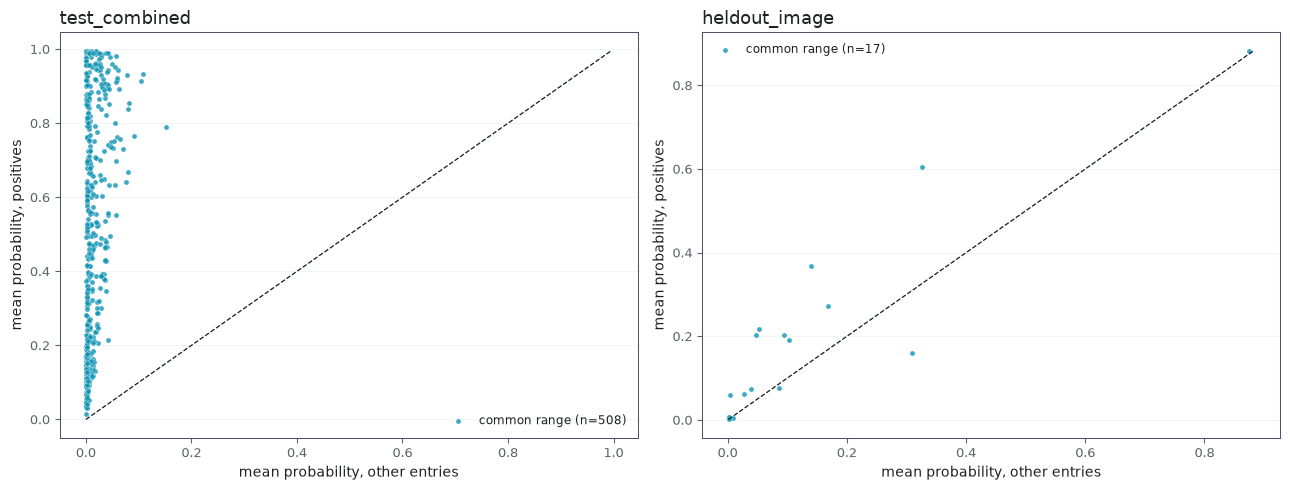

In [8]:
diagnostics = table('extension_diagnostics')
class_means = diagnostics.groupby(['evaluation', 'class_name', 'class_set'], as_index=False)[['positives', 'predicted_positive_rate', 'mean_probability_positive', 'mean_probability_other', 'recall_at_half', 'acquired_fraction']].mean()
display(class_means.groupby(['evaluation', 'class_set'])[['predicted_positive_rate', 'mean_probability_positive', 'mean_probability_other', 'recall_at_half', 'acquired_fraction']].median())
sets = [value for value in figures.CLASS_SET_ORDER if value in set(class_means.class_set)]
figure, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=theme.figure_dpi)
for ax, evaluation in zip(axes, ['test_combined', 'heldout_image']):
    shown = class_means[(class_means.evaluation == evaluation) & (class_means.positives > 0)]
    figures.paired_scatter(shown, x='mean_probability_other', y='mean_probability_positive', hue='class_set', hue_order=sets, xlabel='mean probability, other entries', ylabel='mean probability, positives', title=evaluation, ax=ax, theme=theme)
figure.tight_layout()

### Remarks

- Predicted-positive rate on held-out images is 0.4 % (test: 2.5 %); median recall at 0.5 falls from 0.54 to 0.01.

### Notes

## Probability quantiles by class set

### Methodology

#### Theoretical

Quantiles of $\hat Y$ on positives and on other entries per class set summarise the separation per set.

#### Implementation

`score_by_class_set`, repetition means.

#### Figure descriptions

No figure.

In [9]:
display(table('score_by_class_set').groupby(['evaluation', 'class_set', 'state'])[['q10', 'q25', 'q50', 'q75', 'q90']].mean())

q10         q25         q50         q75         q90
evaluation    class_set state                                                               
heldout_image common    other     0.0000e+00  0.0000e+00  9.5367e-08  1.5616e-06  5.3263e-05
                        positive  1.1334e-02  6.2579e-02  2.0479e-01  6.5276e-01  9.7930e-01
test_combined common    other     7.6377e-11  2.9736e-09  1.1826e-07  9.4420e-06  7.3686e-04
                        positive  2.3400e-01  6.3762e-01  9.2598e-01  9.8562e-01  9.9586e-01

### Remarks

### Notes

## Held-out annotations absent from the head

### Methodology

#### Theoretical

Annotations of the held-out images that were never observed in training cannot be predicted by construction.

#### Implementation

`unseen_heldout_classes`.

#### Figure descriptions

No figure.

In [10]:
display(table('unseen_heldout_classes'))

,ion_index,dataset_id,class_name,mz,in_axis,head_column,class_set
0,0,2024-02-20_01h45m20s,C7H6O4|-H,153.0193,False,-1,not_in_head
1,4,2024-02-20_01h45m20s,C6H8N2O3|-H,155.0462,False,-1,not_in_head
2,12,2024-02-20_01h46m58s,C7H6O4|-H,153.0193,False,-1,not_in_head
3,19,2024-02-20_01h46m58s,C49H86O13P2|-H,943.5471,False,-1,not_in_head
4,30,2024-02-20_01h54m41s,C49H93O12P|[M]-,904.6410,False,-1,not_in_head


### Remarks

- No held-out annotation outside the head that lies on this axis.

### Notes

## Results / Summary

### LLM

- **Observed:** prediction quality is governed by training support: macro AP 0.86 for classes with 1000+ positives, below 0.3 for classes with fewer than 100.
- **Observed:** on held-out images the head predicts almost no positives (0.4 % of entries at 0.5) and per-class recall collapses; positives still receive higher probabilities than other entries (0.16 vs 0.05 median).
- **Interpretation:** the head ranks new-image positives above negatives to some extent but is badly calibrated there; ranking metrics (ROC AUC 0.70) are more informative than threshold metrics on new images.

### Person